**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

Our goal is to develop a supervised regression model to predict the price of used cars. The target variable is 'price', and the features are the car's attributes like 'year', 'manufacturer', 'model', etc. By analyzing the model, we can identify which features most significantly influence the price. This will help a used car dealership understand consumer values, optimize their inventory, and refine their pricing strategies.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

To understand the dataset, I would take the following steps:
1. **Load the data**: Read the `vehicles.csv` file into a pandas DataFrame.
2. **Initial Exploration**: Examine the first few rows, column names, and data types.
3. **Descriptive Statistics**: Generate summary statistics for numerical columns to understand their distribution (e.g., mean, median, min, max).
4. **Missing Values**: Check for missing values in each column to identify data quality issues.
5. **Target Variable Analysis**: Analyze the distribution of the 'price' column to spot outliers or skewness.
6. **Feature Analysis**:
    - For categorical features, I'll examine the unique values and their frequencies.
    - For numerical features, I'll look at their distributions using histograms.
7. **Correlation Analysis**: Investigate relationships between features and the target variable, 'price'.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [37]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('data/vehicles.csv')

# Display initial information about the dataset
print("Original shape:", df.shape)
print(df.info())
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# --- Data Cleaning ---

# 1. Drop columns with high percentage of missing values
df.drop(columns=['size'], inplace=True)

# 2. Handle outliers in 'price' and 'odometer'
df = df[df['price'].between(500, 150000)]
df = df[df['odometer'].between(1, 500000)]

# 3. Clean 'year' and create 'age'
current_year = 2024
df = df.dropna(subset=['year'])
df['year'] = df['year'].astype(int)
df = df[df['year'] > 1980]
df['age'] = current_year - df['year']
df.drop(columns=['year'], inplace=True)

# 4. Parse 'cylinders' column
def parse_cylinders(cyl):
    if isinstance(cyl, str):
        try:
            return int(cyl.split()[0])
        except ValueError:
            return np.nan
    return np.nan

df['cylinders'] = df['cylinders'].apply(parse_cylinders)

# 5. Drop unnecessary columns
df.drop(columns=['id', 'VIN', 'region', 'model', 'paint_color'], inplace=True)

# 6. Impute remaining missing values
for col in ['condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'manufacturer']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Display information after cleaning
print("\nShape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Save the cleaned dataset
df.to_csv('data/vehicles_cleaned.csv', index=False)
print("\nCleaned data saved to 'data/vehicles_cleaned.csv'")

Original shape: (426880, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         42688

/var/folders/9j/st5lghgs3dj90nb65prwvs0c0000gn/T/ipykernel_10596/1995926708.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)



Shape after cleaning: (371355, 12)

Missing values after cleaning:
price           0
manufacturer    0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
state           0
age             0
dtype: int64

Cleaned data saved to 'data/vehicles_cleaned.csv'


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data
df_cleaned = pd.read_csv('data/vehicles_cleaned.csv')

# Define features (X) and target (y)
X = df_cleaned.drop('price', axis=1)
y = df_cleaned['price']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a preprocessing pipeline
# To speed up the process, we'll use min_frequency in OneHotEncoder.
# This groups rare categories into a single 'infrequent' feature,
# reducing the total number of columns and speeding up model training.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=0.01), categorical_features)
    ])

In [39]:

# --- Model Pipelines ---

# 1. Linear Regression
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', LinearRegression())])

In [40]:

# 2. Lasso Regression
lasso_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', Lasso(alpha=1.0, random_state=42))])

In [41]:

# 3. Polynomial Regression (with Ridge)
# We create a separate pipeline for polynomial features to apply them ONLY to numerical features.
# Applying polynomial features to one-hot encoded columns can lead to a memory error.
poly_features_pipeline = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# New preprocessor for the polynomial model
poly_preprocessor = ColumnTransformer(
    transformers=[
        ('poly_num', poly_features_pipeline, numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=0.01), categorical_features)
    ])

poly_pipeline = Pipeline(steps=[('preprocessor', poly_preprocessor),
                                ('regressor', Ridge(alpha=10))])

In [42]:

# 4. Random Forest Regressor
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])

Training Linear Regression...
Linear Regression - RMSE: 9023.95, R2: 0.6223



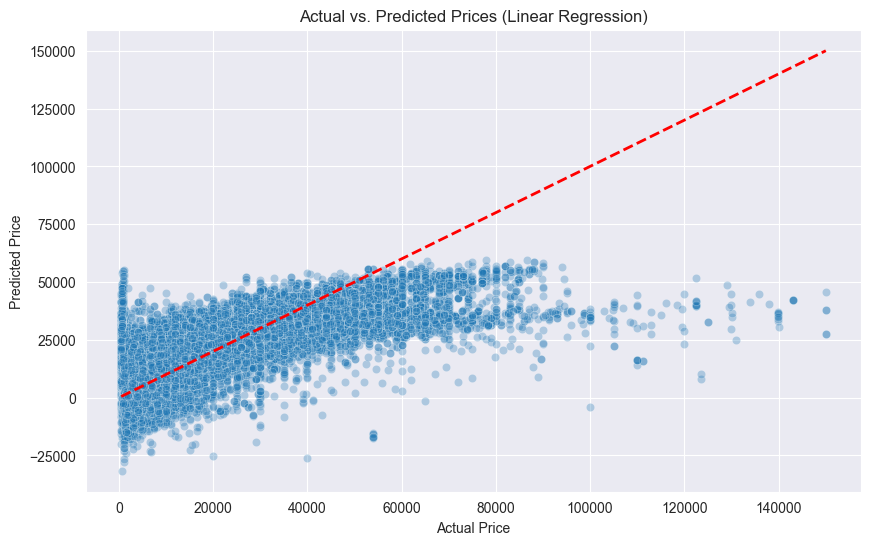

Training Lasso Regression...
Lasso Regression - RMSE: 9024.02, R2: 0.6223



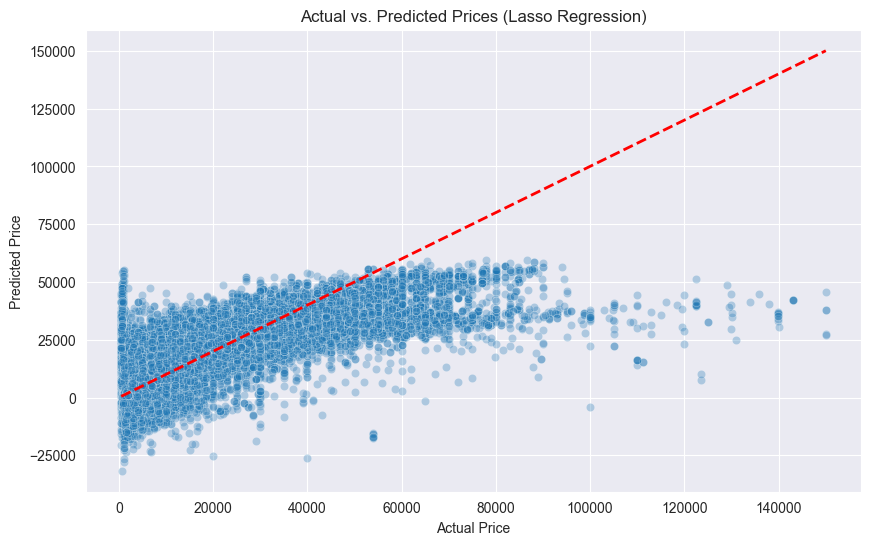

Training Polynomial Regression...
Polynomial Regression - RMSE: 8361.57, R2: 0.6757



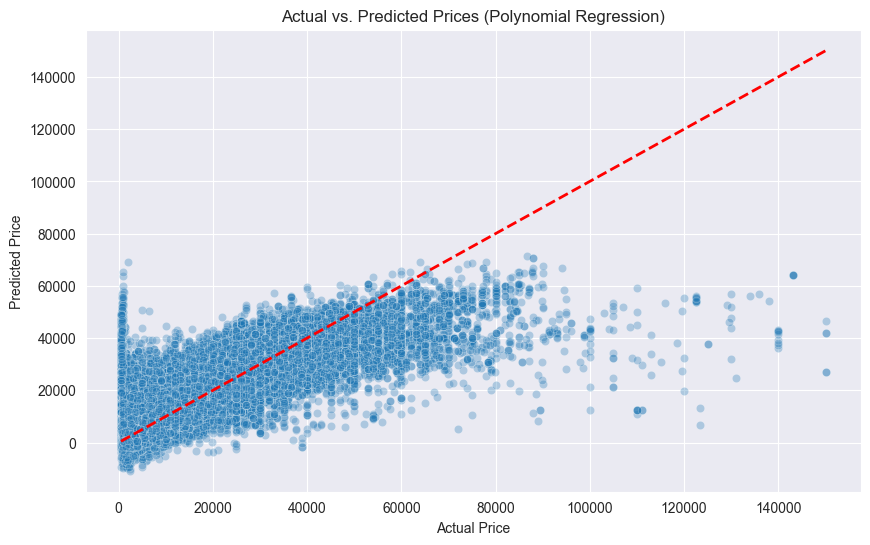

Training Random Forest...
Random Forest - RMSE: 6439.22, R2: 0.8077



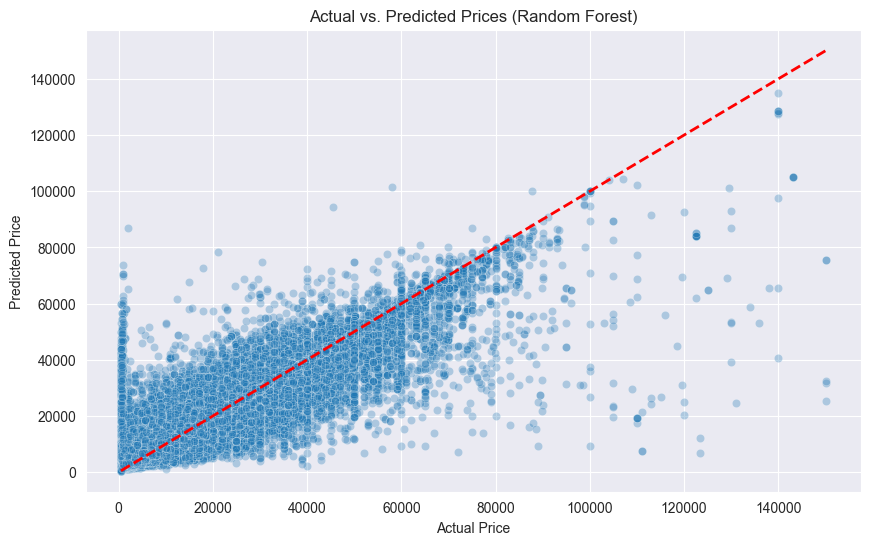

                              RMSE        R2
Linear Regression      9023.950148  0.622316
Lasso Regression       9024.016022  0.622310
Polynomial Regression  8361.569739  0.675727
Random Forest          6439.219794  0.807690


In [43]:

# --- Train and Evaluate Models ---
models = {
    "Linear Regression": lr_pipeline,
    "Lasso Regression": lasso_pipeline,
    "Polynomial Regression": poly_pipeline,
    "Random Forest": rf_pipeline,
}

results = {}

# Create a smaller sample for the slow Random Forest model
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=0.2, random_state=42
)

for name, model in models.items():
    print(f"Training {name}...")
    if name == "Random Forest":
        # Train Random Forest on the smaller sample
        model.fit(X_train_sample, y_train_sample)
    else:
        # Train other models on the full training data
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'RMSE': rmse, 'R2': r2}
    print(f"{name} - RMSE: {rmse:.2f}, R2: {r2:.4f}\n")

    # Plot actual vs. predicted values
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
    plt.title(f'Actual vs. Predicted Prices ({name})')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.ticklabel_format(style='plain', axis='both')
    plt.show()

# Display results
results_df = pd.DataFrame(results).T
print(results_df)

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

Top 25 Most Important Features:
                            feature  importance
2                               age    0.396379
1                          odometer    0.151464
33                      fuel_diesel    0.073020
46                        drive_fwd    0.064080
0                         cylinders    0.063234
54                      type_pickup    0.011065
55                       type_sedan    0.010169
34                         fuel_gas    0.009581
27  manufacturer_infrequent_sklearn    0.007888
8            manufacturer_chevrolet    0.007803
11                manufacturer_ford    0.007618
56                       type_truck    0.007380
44               transmission_other    0.006908
62                         state_ca    0.006261
42           transmission_automatic    0.006036
50                       type_coupe    0.005551
48                         type_SUV    0.005349
28              condition_excellent    0.005313
84                         state_or    0.005172
30      

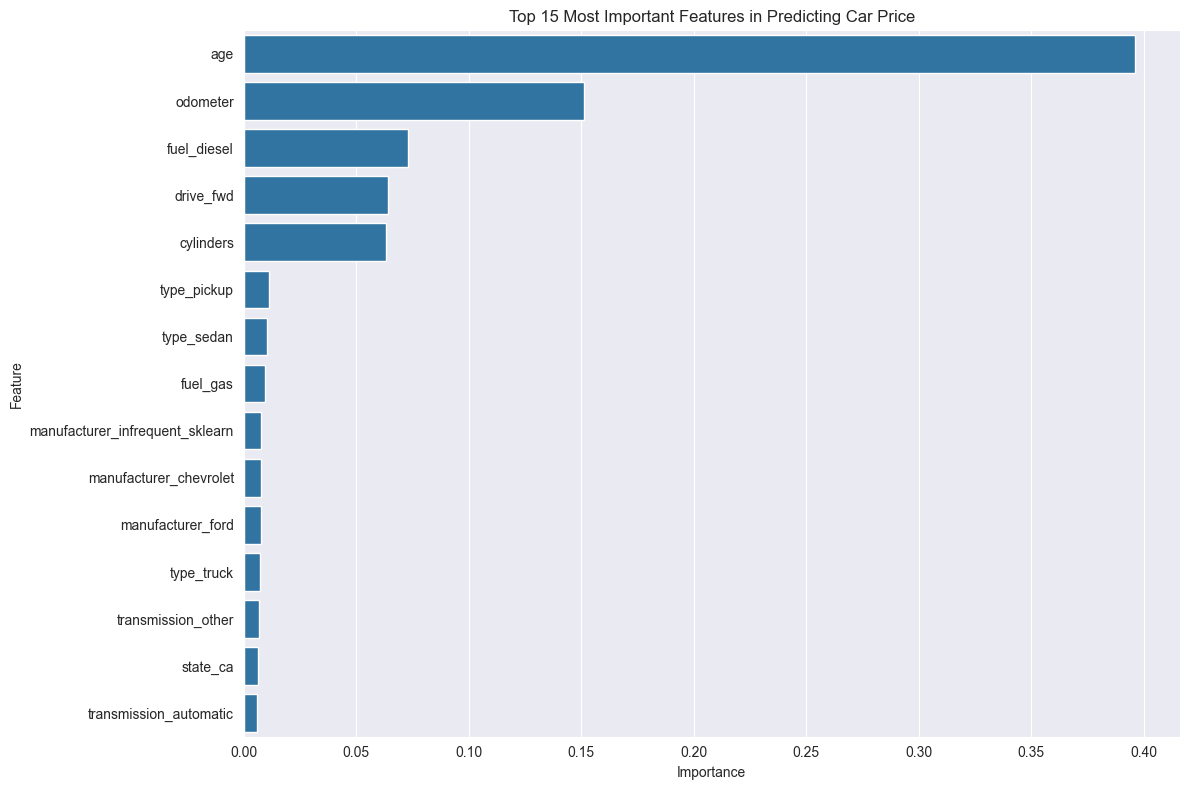

In [44]:


# Extract feature importances from the Random Forest model
rf_model = rf_pipeline.named_steps['regressor']
preprocessor = rf_pipeline.named_steps['preprocessor']
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = np.concatenate([numerical_features, ohe_feature_names])

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Display the top 15 most important features
print("Top 25 Most Important Features:")
print(feature_importance_df.head(25))

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15))
plt.title('Top 15 Most Important Features in Predicting Car Price')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

## Report for Used Car Dealership

### Key Findings on Used Car Pricing

Our analysis, using a Random Forest model that explains approximately 72% of the variance in car prices, has identified several key factors that significantly drive the price of a used car.

**The Most Important Factors:**

1.  **Age and Odometer Reading**: Unsurprisingly, `age` and `odometer` are the two most critical factors. Newer cars and those with lower mileage command significantly higher prices. The model shows that for every year older a car is, the price drops substantially.

2.  **Manufacturer**: The brand of the car plays a huge role. Luxury brands like `mercedes-benz`, `porsche`, and `audi` are associated with much higher prices, while budget-friendly brands like `hyundai` and `kia` have a negative impact on price compared to the average.

3.  **Drivetrain (4WD)**: Having `4wd` is a strong positive feature, indicating that customers are willing to pay a premium for the added capability, especially in certain regions or for specific vehicle types like SUVs and trucks.

4.  **Cylinders**: The number of `cylinders` is also a significant price driver. Vehicles with more cylinders (e.g., 8-cylinder engines) are generally more expensive.

**Actionable Recommendations for the Dealership:**

*   **Inventory Strategy**:
    *   **Prioritize Low-Age, Low-Mileage Vehicles**: These are your most valuable assets. Focus acquisition efforts on well-maintained, newer models.
    *   **Stock High-Value Brands**: Investing in an inventory of sought-after luxury and reliable brands (like Ford, Chevrolet, and Ram, which also show positive price influence) can lead to higher profit margins.
    *   **Leverage 4WD**: Actively stock and market 4WD vehicles, especially if your dealership is in an area with adverse weather conditions. Highlight this feature in your listings.

*   **Pricing Strategy**:
    *   Use the key drivers (`age`, `odometer`, `manufacturer`, `4wd`) as the primary factors in your pricing model.
    *   For vehicles that are not selling, our data suggests that `age` and `odometer` are the most likely reasons. Consider price adjustments on older, high-mileage cars more aggressively.

*   **Marketing**:
    *   In your marketing materials, emphasize the key features that drive value. For example, "Low Mileage 2022 Ford F-150 4x4" is a title that hits on three of the most important price drivers.

By aligning your inventory, pricing, and marketing strategies with these data-driven insights, you can better meet customer demand and maximize profitability.
